In [1]:
import sys
sys.path.append("..")

In [2]:
from project.segmentation.medsam2 import MedSAM2Segmenter
from project.data_io.reader import MedicalImageReader

In [3]:
reader = MedicalImageReader()
image = reader.load("../data/raw/xray/1256842362861431725328351539259305635_u1qifz.png")

In [4]:
segmenter = MedSAM2Segmenter.from_config("../configs/experiments/base.yaml")
objects = segmenter.segment(image)
print(f"Objetos detectados: {len(objects)}")

Objetos detectados: 2


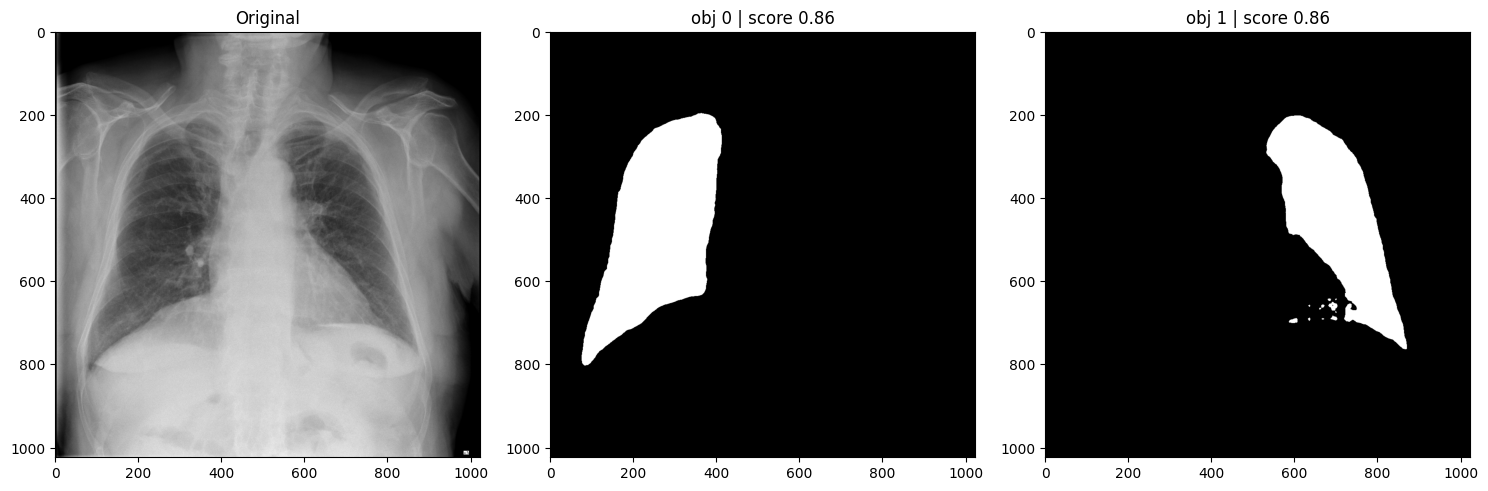

In [5]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, len(objects) + 1, figsize=(15, 5))
axes[0].imshow(image.volume.astype(np.uint8))
axes[0].set_title("Original")

for i, obj in enumerate(objects):
    axes[i+1].imshow(obj.mask, cmap="gray")
    axes[i+1].set_title(f"obj {obj.id} | score {obj.confidence:.2f}")

plt.tight_layout()
plt.show()

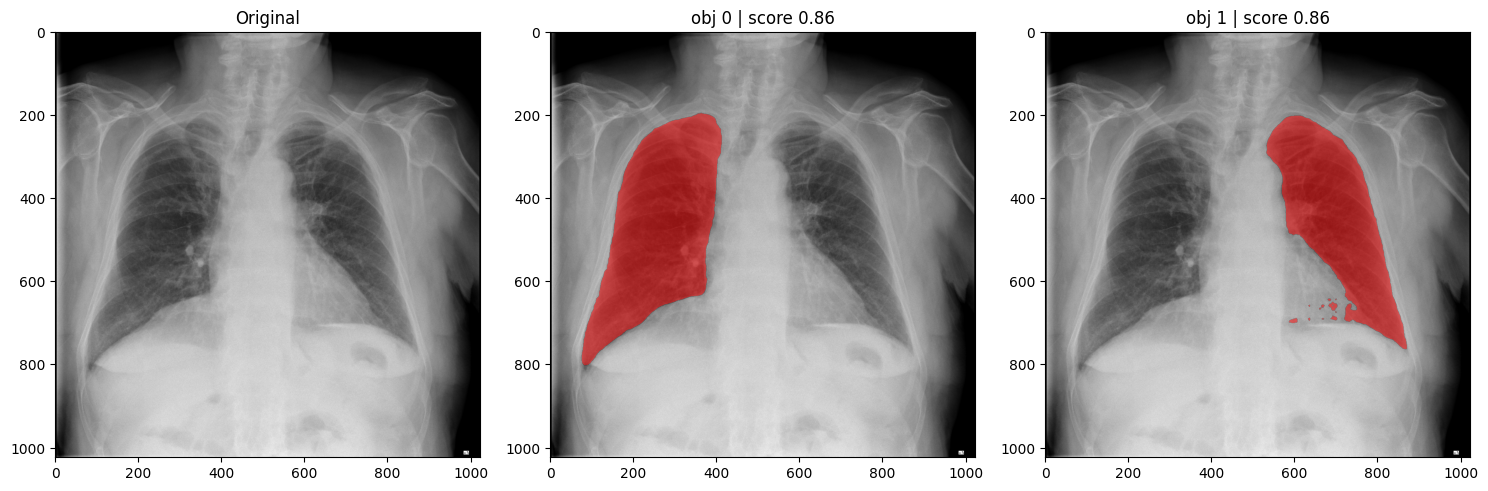

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, len(objects) + 1, figsize=(15, 5))
axes[0].imshow(image.volume.astype(np.uint8))
axes[0].set_title("Original")

for i, obj in enumerate(objects):
    axes[i+1].imshow(image.volume.astype(np.uint8))
    overlay = np.zeros((*obj.mask.shape, 4))  # RGBA
    overlay[obj.mask] = [1, 0, 0, 0.5]        # rojo semitransparente donde hay máscara
    axes[i+1].imshow(overlay)
    axes[i+1].set_title(f"obj {obj.id} | score {obj.confidence:.2f}")

plt.tight_layout()
plt.show()